# Task 2: Restaurant Recommendation

**Objective:** Create a restaurant recommendation system based on user preferences.

**Steps:**
1. Preprocess the dataset by handling missing values and encoding categorical variables.
2. Determine the criteria for restaurant recommendations (e.g., cuisine preference, price range).
3. Implement a content-based filtering approach where users are recommended restaurants similar to their preferred criteria.
4. Test the recommendation system by providing sample user preferences and evaluating the quality of recommendations.

In [1]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import linear_kernel
import warnings
warnings.filterwarnings("ignore")

# Load the dataset
# Replace "CognifyDataset.csv" with the actual filename used in Task 1 if different
df = pd.read_csv("CognifyDataset.csv")
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


### Step 1: Preprocess the Dataset

In [2]:
# Drop rows with missing Cuisines since content-based filtering relies heavily on it
df.dropna(subset=["Cuisines"], inplace=True)

# Reset index after dropping rows
df.reset_index(drop=True, inplace=True)
print("Missing values handled.")

Missing values handled.


### Step 2: Determine Recommendation Criteria

In [3]:
# Criteria we will use:
# - Cuisines (Primary filter for Content-Based similarity)
# - Price range (Filter out restaurants not in preferred budget)
# - Aggregate rating (Sorting metric for quality)

### Step 3: Implement Content-Based Filtering

In [4]:
# Initialize TF-IDF Vectorizer to convert cuisines into a matrix of TF-IDF features
tfidf = TfidfVectorizer(stop_words="english")

# Fit and transform the cuisines text
tfidf_matrix = tfidf.fit_transform(df["Cuisines"])

def recommend_restaurants(preferred_cuisine, preferred_price_range=None, min_rating=0.0, top_n=5):
    """
    Recommends restaurants based on a user preferred cuisine and price range.
    """
    # Convert the user preferred cuisine into the same TF-IDF space
    user_tfidf = tfidf.transform([preferred_cuisine])
    
    # Compute cosine similarities between the user preference and all restaurants
    cosine_similarities = linear_kernel(user_tfidf, tfidf_matrix).flatten()
    
    # Get the indices of restaurants sorted by similarity score (descending)
    related_indices = cosine_similarities.argsort()[::-1]
    
    recommendations = []
    
    for i in related_indices:
        # Stop if we have enough recommendations
        if len(recommendations) >= top_n:
            break
            
        # Check criteria (similarity must be > 0, price range match if specified, min rating)
        if cosine_similarities[i] > 0.0:
            row = df.iloc[i]
            
            if preferred_price_range is not None and row["Price range"] != preferred_price_range:
                continue
                
            if row["Aggregate rating"] < min_rating:
                continue
                
            recommendations.append({
                "Restaurant Name": row["Restaurant Name"],
                "Cuisines": row["Cuisines"],
                "Price range": row["Price range"],
                "Aggregate rating": row["Aggregate rating"],
                "City": row["City"],
                "Similarity Score": round(cosine_similarities[i], 3)
            })
            
    return pd.DataFrame(recommendations)


### Step 4: Test the Recommendation System

In [5]:
# Sample User 1: Loves Italian food, wants a moderate price range (2), and highly rated restaurants (> 4.0)
print("Sample User 1 Recommendations:")
display(recommend_restaurants(preferred_cuisine="Italian", preferred_price_range=2, min_rating=4.0))

print("\n" + "-"*50 + "\n")

# Sample User 2: Looking for Japanese and Sushi, high end (Price range 4)
print("Sample User 2 Recommendations:")
display(recommend_restaurants(preferred_cuisine="Japanese, Sushi", preferred_price_range=4, min_rating=4.5))

Sample User 1 Recommendations:


,Restaurant Name,Cuisines,Price range,Aggregate rating,City,Similarity Score
0,Trattoria Tiramisu,Italian,2,4.1,Davenport,1.000
1,San Carlo,Italian,2,4.3,Manchester,1.000
2,Trattoria Fresco,Italian,2,4.0,Sioux City,1.000
3,Sinyora's,Italian,2,4.0,New Delhi,1.000
4,Puffizza,"Italian, Fast Food",2,4.3,Ahmedabad,0.717



--------------------------------------------------

Sample User 2 Recommendations:


,Restaurant Name,Cuisines,Price range,Aggregate rating,City,Similarity Score
0,Ooma,"Japanese, Sushi",4,4.9,Mandaluyong City,1.000
1,Sushi Leblon,Japanese,4,4.6,Rio de Janeiro,0.669
2,Pa Pa Ya,"Asian, Chinese, Thai, Japanese",4,4.7,New Delhi,0.401
3,Sambo Kojin,"Japanese, Korean",4,4.8,Mandaluyong City,0.399
4,NIU by Vikings,"Seafood, American, Mediterranean, Japanese",4,4.7,Taguig City,0.352


### Step 5: Visualize the Recommendations

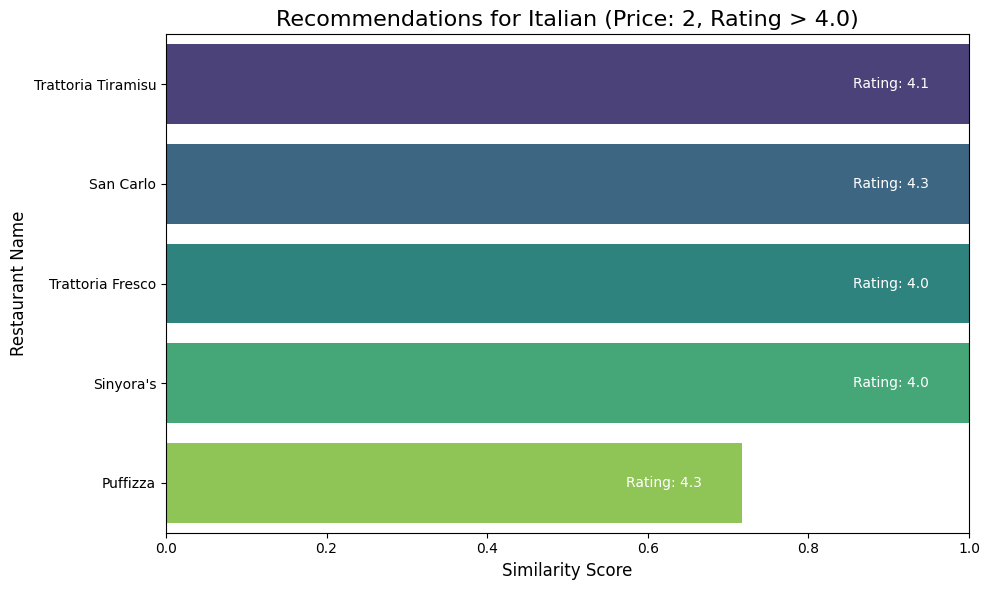

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_recommendations(recommendations_df, title="Top Restaurant Recommendations"):
    if recommendations_df.empty:
        print("No recommendations to visualize.")
        return
        
    plt.figure(figsize=(10, 6))
    
    # Create a bar plot of Similarity Score by Restaurant Name
    sns.barplot(x="Similarity Score", y="Restaurant Name", data=recommendations_df, palette="viridis")
    
    # Add labels and title
    plt.title(title, fontsize=16)
    plt.xlabel("Similarity Score", fontsize=12)
    plt.ylabel("Restaurant Name", fontsize=12)
    plt.xlim(0, 1.0)
    
    # Display aggregate rating on the bars
    for index, row in recommendations_df.iterrows():
        plt.text(row['Similarity Score'] - 0.05, index, f"Rating: {row['Aggregate rating']}", color='white', ha='right', va='center')
        
    plt.tight_layout()
    plt.show()

# Get recommendations for Sample User 1
recs_user1 = recommend_restaurants(preferred_cuisine="Italian", preferred_price_range=2, min_rating=4.0)

# Visualize
plot_recommendations(recs_user1, title="Recommendations for Italian (Price: 2, Rating > 4.0)")
